<a href="https://colab.research.google.com/github/EmptyRain75/mnist-ai-classifier/blob/main/notebooks/05_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for MNIST Classification

## Objective

The previous MLP introduced nonlinear hidden representations, but it still flattened each MNIST image into a 784-dimensional vector.

```text
1 × 28 × 28
    ↓
Flatten
    ↓
784
```

This removes the explicit 2D spatial structure of the image.

A Convolutional Neural Network (CNN) instead processes the image directly:

```text
1 × 28 × 28
      ↓
Convolution
      ↓
Feature Maps
      ↓
Pooling
      ↓
Deeper Features
      ↓
Classifier
      ↓
10 logits
```

In this notebook, we will:

1. Load MNIST while preserving the image shape.
2. Build a basic CNN in PyTorch.
3. Track tensor shapes through the network.
4. Train the CNN using Cross Entropy and SGD.
5. Evaluate train, validation, and test accuracy.
6. Compare the CNN conceptually with the previous MLP.

## Module 1 — Load MNIST

MNIST images are loaded as tensors with shape:

```text
(batch_size, channels, height, width)
```

For MNIST:

```text
N × 1 × 28 × 28
```

where:

- `N` = batch size
- `1` = grayscale channel
- `28 × 28` = image dimensions

Unlike the MLP, the CNN keeps this spatial representation.

In [ ]:
import time

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
def load_mnist(
    batch_size=32,
    val_size=10000,
    seed=42
):
    transform = transforms.ToTensor()

    full_train_dataset = datasets.MNIST(
        root="data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.MNIST(
        root="data",
        train=False,
        download=True,
        transform=transform
    )

    train_size = len(full_train_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed)
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [ ]:
train_loader, val_loader, test_loader = load_mnist()

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])


### Visual Check — MNIST Samples

Before building the CNN, we inspect several input images.

The CNN receives these images directly in their `1 × 28 × 28` spatial form rather than flattening them first.

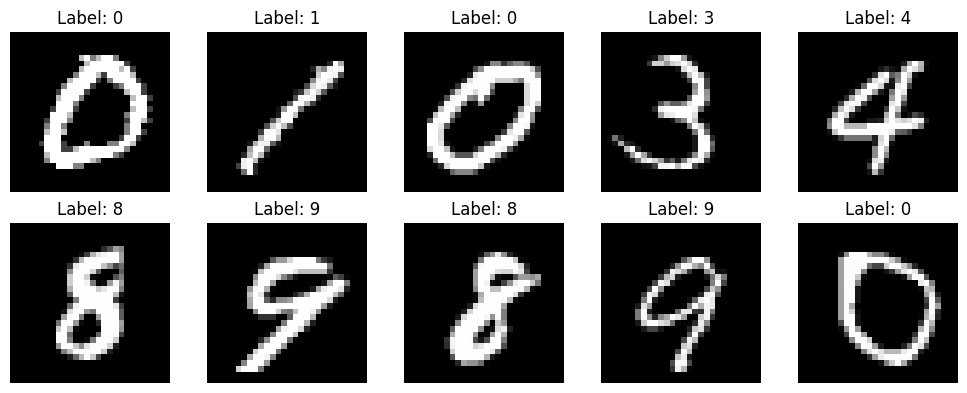

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Module 2 — CNN Architecture and Shape Tracking

The main limitation of the MLP is that it flattens the image immediately:

```text
1 × 28 × 28
    ↓
Flatten
    ↓
784
```

This removes the explicit 2D spatial structure.

A CNN keeps the image in spatial form and learns local patterns such as edges, curves, and shapes using convolutional filters.

Our baseline CNN will use:

```text
Input
1 × 28 × 28

↓

Conv2d
1 → 32 channels
3 × 3 kernel
padding = 1

↓

32 × 28 × 28

↓

ReLU

↓

MaxPool2d
2 × 2

↓

32 × 14 × 14

↓

Conv2d
32 → 64 channels
3 × 3 kernel
padding = 1

↓

64 × 14 × 14

↓

ReLU

↓

MaxPool2d
2 × 2

↓

64 × 7 × 7

↓

Flatten

↓

3136 features

↓

Linear

↓

10 logits
```

### Convolution

A convolutional layer applies small learnable filters across local regions of the image.

```text
Input image
   ↓
3 × 3 filter slides across image
   ↓
Feature map
```

Important parameters:

- `in_channels` — number of input channels
- `out_channels` — number of learned filters / output feature maps
- `kernel_size` — size of each filter
- `stride` — how far the filter moves each step
- `padding` — pixels added around the image border

For a convolution, the spatial output size is:

```text
output_size = floor((input + 2 × padding - kernel_size) / stride) + 1
```

For our first layer:

```text
input   = 28
kernel  = 3
padding = 1
stride  = 1
```

so:

```text
output = 28
```

Therefore:

```text
1 × 28 × 28
    ↓
Conv2d(1 → 32)
    ↓
32 × 28 × 28
```

### Why Multiple Channels?

Each convolutional filter can learn a different local pattern.

```text
Filter 1 → one type of feature
Filter 2 → another feature
...
Filter 32 → another feature
```

So `out_channels=32` produces 32 feature maps.

### ReLU

ReLU introduces nonlinearity:

```text
ReLU(x) = max(0, x)
```

Without nonlinear activation functions, stacking multiple linear/convolutional layers would still behave like a linear transformation.

### Max Pooling

Max pooling reduces the spatial dimensions.

For:

```text
MaxPool2d(kernel_size=2)
```

each `2 × 2` region becomes one value.

```text
32 × 28 × 28
      ↓
MaxPool2d(2)
      ↓
32 × 14 × 14
```

Pooling:

- reduces computation,
- reduces the size of later feature maps,
- makes the representation less sensitive to small spatial shifts.

### Shape Tracking

The complete shape progression is:

| Layer | Output Shape |
|---|---|
| Input | `1 × 28 × 28` |
| Conv1 | `32 × 28 × 28` |
| ReLU | `32 × 28 × 28` |
| Pool1 | `32 × 14 × 14` |
| Conv2 | `64 × 14 × 14` |
| ReLU | `64 × 14 × 14` |
| Pool2 | `64 × 7 × 7` |
| Flatten | `3136` |
| Linear | `10` |

The key architectural difference is:

```text
MLP
Flatten immediately
    ↓
Learn from individual pixel values

CNN
Convolution first
    ↓
Learn local spatial features
    ↓
Flatten only near the classifier
```

In [ ]:
conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=32,
    kernel_size=3,
    padding=1
)

pool = nn.MaxPool2d(kernel_size=2)

x = images

print("Input :", x.shape)

x = conv1(x)
print("Conv1 :", x.shape)

x = pool(x)
print("Pool1 :", x.shape)

Input : torch.Size([32, 1, 28, 28])
Conv1 : torch.Size([32, 32, 28, 28])
Pool1 : torch.Size([32, 32, 14, 14])


## Module 3 — Define the CNN

We now combine the layers from Module 2 into a reusable PyTorch model.

The CNN has two parts:

```text
Feature Extractor
Conv → ReLU → Pool
Conv → ReLU → Pool

        ↓

Classifier
Flatten → Linear → 10 logits
```

The convolutional layers learn spatial features, while the final linear layer maps those features to the 10 MNIST classes.

The model returns **logits**, not probabilities.

`nn.CrossEntropyLoss()` will handle the Softmax operation internally during training.

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(
            kernel_size=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(
            kernel_size=2
        )

        self.fc = nn.Linear(
            64 * 7 * 7,
            num_classes
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = torch.flatten(x, start_dim=1)

        x = self.fc(x)

        return x

In [ ]:
model = CNN()

print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)


In [ ]:
sample_output = model(images)

print("Input shape :", images.shape)
print("Output shape:", sample_output.shape)

Input shape : torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])


The output shape is:

```text
batch_size × number_of_classes
```

For a batch of 32 MNIST images:

```text
32 × 10
```

Each row contains 10 logits, one for each digit class.

The predicted class is:

```python
prediction = argmax(logits)
```

The model architecture is now complete. The next step is to define the loss function and optimizer.

## Module 4 — Loss and Optimizer

The CNN outputs 10 logits for each image.

For multiclass classification, we use:
Cross Entropy Loss


PyTorch's `nn.CrossEntropyLoss()` expects raw logits, so we do **not** apply Softmax manually inside the model.

For optimization, we keep the same simple setup used in the previous models:

```text
Optimizer: SGD
Learning rate: 0.1
```

This keeps the comparison focused on the architectural change from MLP to CNN rather than optimization tricks.

In [ ]:
criterion = nn.CrossEntropyLoss()

learning_rate = 0.1

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

In [ ]:
logits = model(images)

loss = criterion(
    logits,
    labels
)

print("Logits shape:", logits.shape)
print("Loss:", loss.item())

Logits shape: torch.Size([32, 10])
Loss: 2.3042080402374268


The training objective is now:

```text
Images
  ↓
CNN
  ↓
Logits
  ↓
Cross Entropy
  ↓
Loss
  ↓
Backpropagation
  ↓
SGD update
```

The loss and optimization pipeline is therefore reused from the MLP stage.

Only the model architecture has changed.

## Module 5 — Training Loop

The training loop is almost identical to the MLP stage.

For each batch:

```text
Images
  ↓
Forward pass
  ↓
Logits
  ↓
Cross Entropy Loss
  ↓
Clear old gradients
  ↓
Backpropagation
  ↓
SGD update
```

The important point is that the **training process is reused**, just adding a conv to extract local features.

The main change from the MLP is only the model architecture (adding the conv before the feed foward network).

In [ ]:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    n_epochs=10
):
    loss_history = []

    start_time = time.perf_counter()

    for epoch in range(n_epochs):
        model.train()

        epoch_loss = 0.0

        for images, labels in train_loader:

            # Forward pass
            logits = model(images)

            # Compute loss
            loss = criterion(
                logits,
                labels
            )

            # Clear old gradients
            optimizer.zero_grad()

            # Backpropagation
            loss.backward()

            # Update parameters
            optimizer.step()

            epoch_loss += loss.item()

        average_loss = (
            epoch_loss / len(train_loader)
        )

        loss_history.append(
            average_loss
        )

        print(
            f"Epoch {epoch + 1}/{n_epochs} | "
            f"Loss: {average_loss:.4f}"
        )

    training_time = (
        time.perf_counter() - start_time
    )

    return loss_history, training_time

In [ ]:
n_epochs = 10

loss_history, training_time = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    n_epochs=n_epochs
)

Epoch 1/10 | Loss: 0.1865
Epoch 2/10 | Loss: 0.0663
Epoch 3/10 | Loss: 0.0488
Epoch 4/10 | Loss: 0.0399
Epoch 5/10 | Loss: 0.0338
Epoch 6/10 | Loss: 0.0284
Epoch 7/10 | Loss: 0.0249
Epoch 8/10 | Loss: 0.0210
Epoch 9/10 | Loss: 0.0187
Epoch 10/10 | Loss: 0.0161


### Training Loss

The loss should generally decrease as the CNN learns from the training data.

This provides a simple visual check that optimization is progressing.

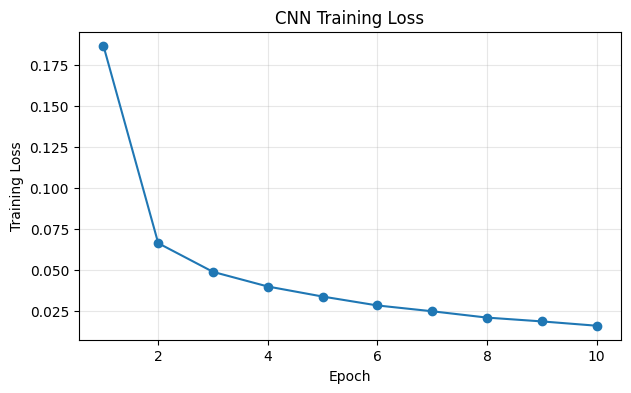

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")
plt.grid(alpha=0.3)

plt.show()

The CNN is now training end-to-end.

During backpropagation, PyTorch automatically computes gradients through:

```text
Linear layer
    ↓
Pooling
    ↓
ReLU
    ↓
Convolution
    ↓
Earlier convolution layers
```

The convolution filters are therefore learned from the classification loss in the same way that the MLP's weights were learned.

No manual gradient derivation is required because PyTorch's autograd handles the backward pass.

## Module 6 — Evaluation

During evaluation, the model should not update its parameters.

We therefore use:

```text
model.eval()
torch.no_grad()
```

For each batch:

```text
Images
  ↓
CNN
  ↓
10 logits
  ↓
argmax
  ↓
Predicted class
```

Accuracy is then calculated by comparing the predictions with the true labels.

In [ ]:
def evaluate(model, data_loader):
    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():
        for images, labels in data_loader:

            logits = model(images)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total

In [ ]:
train_accuracy = evaluate(
    model,
    train_loader
)

val_accuracy = evaluate(
    model,
    val_loader
)

test_accuracy = evaluate(
    model,
    test_loader
)

print("Results")
print("-------")
print(f"Training time      : {training_time:.2f} s")
print(f"Training accuracy  : {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Test accuracy      : {test_accuracy:.4f}")

Results
-------
Training time      : 352.28 s
Training accuracy  : 0.9958
Validation accuracy: 0.9872
Test accuracy      : 0.9895


### Visual Check — Model Predictions

Accuracy summarizes overall performance, but inspecting individual predictions helps verify what the classifier is actually doing.

Correct and incorrect predictions can be viewed directly on MNIST samples.

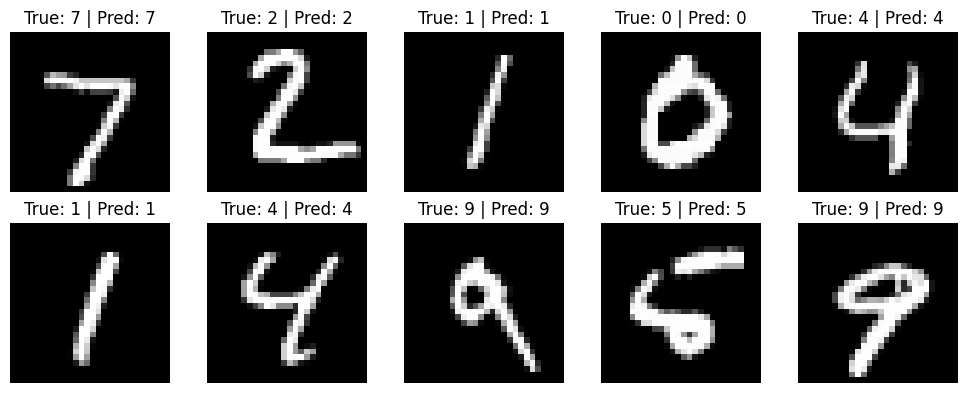

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    logits = model(images)
    predictions = torch.argmax(logits, dim=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")

    ax.set_title(
        f"True: {labels[i].item()} | "
        f"Pred: {predictions[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### Visualizing Learned Feature Maps

Unlike the MLP, the CNN does not immediately flatten the image.

The first convolutional layer transforms the original image into multiple **feature maps**.

Each channel is produced by a different learned filter and responds to different local patterns in the image.

We can inspect several feature maps produced by the trained first convolutional layer.

In [ ]:
sample_image = images[0:1]

with torch.no_grad():
    feature_maps = model.conv1(sample_image)
    feature_maps = model.relu1(feature_maps)

print("Input shape       :", sample_image.shape)
print("Feature map shape :", feature_maps.shape)

Input shape       : torch.Size([1, 1, 28, 28])
Feature map shape : torch.Size([1, 32, 28, 28])


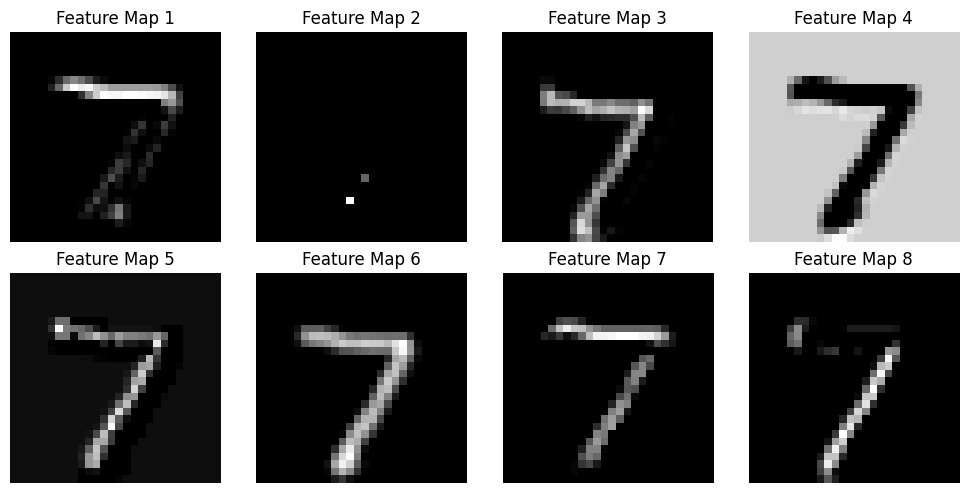

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        feature_maps[0, i].detach(),
        cmap="gray"
    )

    ax.set_title(f"Feature Map {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

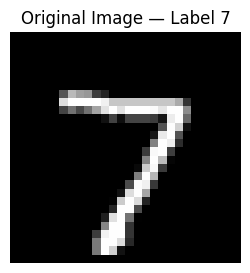

In [ ]:
plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0, 0], cmap="gray")
plt.title(f"Original Image — Label {labels[0].item()}")
plt.axis("off")
plt.show()

## Module 7 — From MLP to CNN

The transition from MLP to CNN is mainly a change in **how features are represented and transformed**.

An MLP relies on fully connected layers:

```text
Image
1 × 28 × 28
    ↓
Flatten
    ↓
784
    ↓
Fully Connected Layers
    ↓
10 logits
```

A CNN introduces convolutional layers that operate directly on spatial feature maps:

```text
Image
1 × 28 × 28
    ↓
Convolution
    ↓
Spatial Feature Maps
    ↓
Convolution / Pooling
    ↓
Higher-level Feature Maps
    ↓
Classifier
    ↓
10 logits
```

The defining feature of a CNN is therefore not simply that it appears before an MLP.

It is the use of **convolutional operations with local connectivity and shared weights** to learn spatial representations.

### CNN and Fully Connected Layers

A CNN classifier may still contain fully connected layers at the end.

Our model uses:

```text
Convolutional Feature Extractor
        ↓
64 × 7 × 7
        ↓
Flatten
        ↓
Linear
        ↓
10 logits
```

However, fully connected layers are not strictly required.

A network can remain convolutional much further into the architecture.

For example:

```text
64 × 7 × 7
    ↓
Conv 7×7
    ↓
128 × 1 × 1
    ↓
Conv 1×1
    ↓
10 × 1 × 1
```

Once the spatial dimensions are `1 × 1`, a `1 × 1` convolution behaves like a fully connected transformation across channels.

More generally, a `1 × 1` convolution performs the same learned linear transformation across the channel dimension at every spatial location.

### Architectural Progression

The progression in this project can therefore be viewed as:

```text
Softmax Regression
Raw pixels
    ↓
Linear mapping

        ↓ add nonlinear hidden representation

MLP
Flattened pixels
    ↓
Fully connected nonlinear representation

        ↓ introduce spatially structured operations

CNN
Image / Feature Maps
    ↓
Local convolutional processing
    ↓
Hierarchical spatial representation
    ↓
Classification
```

The CNN is therefore a distinct architectural idea, but it can still reuse concepts from fully connected networks.

The important upgrade is the introduction of:

```text
Local connectivity
Weight sharing
Spatial feature maps
Hierarchical feature extraction
```

rather than simply adding one extra preprocessing step before an MLP.

## Conclusion

In this notebook, we extended the MNIST classifier from fully connected processing to a **convolutional architecture designed for spatial data**.

The main architectural change was:

```text
MLP
Image
  ↓
Flatten immediately
  ↓
Fully connected representation
  ↓
Classifier

CNN
Image
  ↓
Convolutional processing
  ↓
Learned spatial feature maps
  ↓
Pooling / deeper convolution
  ↓
Classifier
```

Unlike the MLP, the CNN does not need to destroy the image's spatial structure at the beginning.

Instead, convolution operates locally on the image using **shared filters**, allowing the network to learn spatial patterns such as edges, curves, and progressively higher-level features.

The main new concepts were:

```text
Convolution
Kernels / Filters
Local connectivity
Weight sharing
Feature maps
Channels
Stride
Padding
Pooling
Spatial shape tracking
```

At the same time, many components from the MLP stage were reused:

```text
ReLU
Cross Entropy
Backpropagation
SGD
Train / Validation / Test
Evaluation
```

The architectural progression so far is:

```text
Softmax Regression
Raw pixels
    ↓
Linear mapping

        ↓ add nonlinear hidden representation

MLP
Flattened pixels
    ↓
Fully connected nonlinear representation

        ↓ introduce spatially structured operations

CNN
Image / feature maps
    ↓
Local convolutional processing
    ↓
Hierarchical spatial representation
    ↓
Classification
```

The major upgrade from MLP to CNN is therefore:

```text
MLP
Learn from flattened pixels using fully connected layers

CNN
Learn directly from spatial feature maps
using local connections and shared weights
```

In our baseline model, the convolutional feature maps are eventually flattened and passed to a linear classifier:

```text
Conv / Pool
    ↓
64 × 7 × 7
    ↓
Flatten
    ↓
Linear
    ↓
10 logits
```

However, this classifier head is **not what defines a CNN**.

Other CNN architectures may use deeper fully connected heads, Global Average Pooling, or remain convolutional much further into the network. Fully connected operations can also sometimes be expressed using convolutions depending on the spatial dimensions.

The next stage is the **Vision Transformer**, which introduces a different strategy for processing image structure:

```text
Image
  ↓
Patches
  ↓
Patch Embeddings
  ↓
Self-Attention
  ↓
Classification
```

Instead of using convolution as its primary spatial operation, the Vision Transformer will learn relationships between image patches through self-attention.

Further CNN optimization techniques such as Batch Normalization, Adam, data augmentation, residual connections, and other training improvements are intentionally postponed to the `experiments/` stage.